# Section 1: Setup and Databset Init
Import SparkSession from pyspark.sql, and initialize a SparkSession. Also import all the necessary functions from pyspark.sql.functions and all necessary classes from pyspark.sql.types

In [1]:
import os
import sys

from pyspark.sql.functions import broadcast, explode, split, col, avg, round, desc
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = SparkSession.builder \
    .appName("Week 6 Project 1 Works") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/10 14:08:32 WARN Utils: Your hostname, Mostafizurs-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.171 instead (on interface en0)
26/03/10 14:08:32 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/10 14:08:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# Create a SparkSession called 'spark'
spark = SparkSession.builder \
    .appName("Week 6 Project 1 Works")\
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")  # Suppress warnings for cleaner output

## Users
This is the given schema for the users dataset in the README:

UserID::Gender::Age::Occupation::Zip-code


In [3]:
schema_users = StructType([
    StructField("UserID", IntegerType(), True),
    StructField("Gender", StringType(), True),
    StructField("Age", IntegerType(), True),
    StructField("Occupation",IntegerType(), True),
    StructField("Zip-code", StringType(), True)
])

df_users = spark.read \
    .option("header", "false") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .option("sep", "::") \
    .schema(schema_users) \
    .csv("./ml-1m/users.dat")

Print the schema of the users table:

In [4]:
df_users.printSchema()

root
 |-- UserID: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Occupation: integer (nullable = true)
 |-- Zip-code: string (nullable = true)



How many entries in the users table?

In [5]:
df_users.count()

6040

Show a few rows from the users table:

In [6]:
df_users.show(5)

+------+------+---+----------+--------+
|UserID|Gender|Age|Occupation|Zip-code|
+------+------+---+----------+--------+
|     1|     F|  1|        10|   48067|
|     2|     M| 56|        16|   70072|
|     3|     M| 25|        15|   55117|
|     4|     M| 45|         7|   02460|
|     5|     M| 25|        20|   55455|
+------+------+---+----------+--------+
only showing top 5 rows


## Ratings 
This is the given schema for the ratings dataset in the README:

UserID::MovieID::Rating::Timestamp

In [7]:
schema_ratings  = StructType([
    StructField("UserID", IntegerType(), True),
    StructField("MovieID", IntegerType(), True),
    StructField("Rating", IntegerType(), True),
    StructField("Timestamp",IntegerType(), True)
])

df_ratings = spark.read \
    .option("header", "false") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .option("sep", "::") \
    .schema(schema_ratings) \
    .csv("./ml-1m/ratings.dat")

df_ratings.show(5)

+------+-------+------+---------+
|UserID|MovieID|Rating|Timestamp|
+------+-------+------+---------+
|     1|   1193|     5|978300760|
|     1|    661|     3|978302109|
|     1|    914|     3|978301968|
|     1|   3408|     4|978300275|
|     1|   2355|     5|978824291|
+------+-------+------+---------+
only showing top 5 rows


Print the schema of the ratings table:

In [8]:
df_ratings.printSchema()

root
 |-- UserID: integer (nullable = true)
 |-- MovieID: integer (nullable = true)
 |-- Rating: integer (nullable = true)
 |-- Timestamp: integer (nullable = true)



How many entries in the ratings table?

In [9]:
df_ratings.count()

1000209

Show a few rows from the ratings table:

In [10]:
df_ratings.show(5)

+------+-------+------+---------+
|UserID|MovieID|Rating|Timestamp|
+------+-------+------+---------+
|     1|   1193|     5|978300760|
|     1|    661|     3|978302109|
|     1|    914|     3|978301968|
|     1|   3408|     4|978300275|
|     1|   2355|     5|978824291|
+------+-------+------+---------+
only showing top 5 rows


## Movies 
This is the given schema for the movies dataset in the README:

MovieID::Title::Genres

In [11]:
schema_movies  = StructType([
    StructField("MovieID", IntegerType(), True),
    StructField("Title", StringType(), True),
    StructField("Genres",StringType(), True)
])

df_movies = spark.read \
    .option("header", "false") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .option("sep", "::") \
    .schema(schema_movies) \
    .csv("./ml-1m/movies.dat")



Print the schema of the movie table:

In [12]:
df_movies.printSchema()

root
 |-- MovieID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Genres: string (nullable = true)



How many entries in the moveis table?

In [13]:
df_movies.count()

3883

Show a few rows from the movies table:

In [14]:
df_movies.show(5)

+-------+--------------------+--------------------+
|MovieID|               Title|              Genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Animation|Childre...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|        Comedy|Drama|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows


# Section 2: Join the Tables
Ratings is joined with Movies on MovieID, and joined with Users on UserID, and the result is stored in df_joined.

In [15]:
df_joined = df_ratings \
    .join(broadcast(df_users), on="UserID", how="inner") \
    .join(broadcast(df_movies), on="MovieID", how="inner")

Print the schema of the joined tables:

In [16]:
df_joined.printSchema()

root
 |-- MovieID: integer (nullable = true)
 |-- UserID: integer (nullable = true)
 |-- Rating: integer (nullable = true)
 |-- Timestamp: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Occupation: integer (nullable = true)
 |-- Zip-code: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Genres: string (nullable = true)



How many columns in the joined table?

In [17]:
len(df_joined.columns)

10

How many entries in the joined table?

In [18]:
df_joined.count()

1000209

Show a few entries from the joined table:

In [19]:
df_joined.show(5)

+-------+------+------+---------+------+---+----------+--------+--------------------+--------------------+
|MovieID|UserID|Rating|Timestamp|Gender|Age|Occupation|Zip-code|               Title|              Genres|
+-------+------+------+---------+------+---+----------+--------+--------------------+--------------------+
|   1193|     1|     5|978300760|     F|  1|        10|   48067|One Flew Over the...|               Drama|
|    661|     1|     3|978302109|     F|  1|        10|   48067|James and the Gia...|Animation|Childre...|
|    914|     1|     3|978301968|     F|  1|        10|   48067| My Fair Lady (1964)|     Musical|Romance|
|   3408|     1|     4|978300275|     F|  1|        10|   48067|Erin Brockovich (...|               Drama|
|   2355|     1|     5|978824291|     F|  1|        10|   48067|Bug's Life, A (1998)|Animation|Childre...|
+-------+------+------+---------+------+---+----------+--------+--------------------+--------------------+
only showing top 5 rows


Explain the join operation:

In [20]:
df_joined.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [MovieID#37, UserID#36, Rating#38, Timestamp#39, Gender#1, Age#2, Occupation#3, Zip-code#4, Title#84, Genres#85]
   +- BroadcastHashJoin [MovieID#37], [MovieID#83], Inner, BuildRight, false
      :- Project [UserID#36, MovieID#37, Rating#38, Timestamp#39, Gender#1, Age#2, Occupation#3, Zip-code#4]
      :  +- BroadcastHashJoin [UserID#36], [UserID#0], Inner, BuildRight, false
      :     :- Filter (isnotnull(UserID#36) AND isnotnull(MovieID#37))
      :     :  +- FileScan csv [UserID#36,MovieID#37,Rating#38,Timestamp#39] Batched: false, DataFilters: [isnotnull(UserID#36), isnotnull(MovieID#37)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/Volumes/Documents/sfbu/sfbu/cs570_movie-lens_group2/ml-1m/rating..., PartitionFilters: [], PushedFilters: [IsNotNull(UserID), IsNotNull(MovieID)], ReadSchema: struct<UserID:int,MovieID:int,Rating:int,Timestamp:int>
      :     +- BroadcastExchange HashedRelationBroadcastMod

# Section 3: Basic Statistics

In [21]:
df_joined.describe().show()

[Stage 23:>                                                         (0 + 1) / 1]

+-------+------------------+------------------+------------------+--------------------+-------+------------------+-----------------+-----------------+--------------------+-------+
|summary|           MovieID|            UserID|            Rating|           Timestamp| Gender|               Age|       Occupation|         Zip-code|               Title| Genres|
+-------+------------------+------------------+------------------+--------------------+-------+------------------+-----------------+-----------------+--------------------+-------+
|  count|           1000209|           1000209|           1000209|             1000209|1000209|           1000209|          1000209|          1000209|             1000209|1000209|
|   mean|1865.5398981612843| 3024.512347919285| 3.581564453029317| 9.722436954046655E8|   NULL| 29.73831369243828|8.036138447064564|223239.8917114074|                NULL|   NULL|
| stddev|  1096.04068945728|1728.4126948999556|1.1171018453732602|1.2152558939921338E7|   NULL|11.75

## Observations
- Despite the zipcode being cast as a string rather than an integer, they describe() still calculates a numerical mean and standard deviation. Zipcodes are fixed, location based entries, and have no correlation to each other.
- The Age column is cast as an integer, but it is a categorical variable, as it represents age groups, not distinct ages. At first glance, seeing the minimum age as 1 is odd, but it is a valid entry.
- The Occupation column is cast as an integer, but it is a categorical variable, as it represents occupation groups, not distinct occupations. Executing operations of mean and standard deviation on this column is not valid.

# Section 4: EDA Questions
1. *How many unique genres appear in the dataset? Remember that the Genres column
contains pipe-separated values (e.g., “Action|Comedy”). Count the distinct individual
genres, not the distinct genre combinations.*
2. *What is the average rating given by users in the 25–34 age group? Report to at
least two decimal places.*
3. *Which movie has the most ratings, and how many ratings does it have? Report
both the movie title and the count.*

In [22]:
# --- Question 1: Unique Genres ---
# Split the genres string by pipe and explode into separate rows
df_genres = df_movies.withColumn("Genre", explode(split(col("Genres"), "\\|")))
unique_genres_count = df_genres.select("Genre").distinct().count()
print(f"A. Number of unique genres: {unique_genres_count}")

# --- Question 2: Average rating for 25-34 age group ---
# In MovieLens 1M dataset, Age=25 represents the 25-34 age bracket
avg_rating_row = (
    df_joined.filter(col("Age") == 25)
    .agg(round(avg("Rating"), 2).alias("AvgRating"))
    .collect()[0]
)
print(f"B. Average rating for 25-34 age group: {avg_rating_row['AvgRating']:.2f}")

# --- Question 3: Movie with the most ratings ---
most_rated_movie = df_joined.groupBy("Title").count().orderBy(desc("count")).first()
print(
    f"C. Movie with most ratings: '{most_rated_movie['Title']}' with {most_rated_movie['count']} ratings"
)

A. Number of unique genres: 18


B. Average rating for 25-34 age group: 3.55


[Stage 39:>                                                         (0 + 1) / 1]

C. Movie with most ratings: 'American Beauty (1999)' with 3428 ratings


### Question 1. How many unique genres appear in the dataset?
*Answer*: 18 unique genres. 
*Code implementation*: We exploded the pipe-separated Genres column into separate rows using the explode and split functions, then counted the distinct genres.

### Question 2. What is the average rating given by users in the 25–34 age group?
*Answer*: 3.55. 
*Code implementation*: We filtered df_joined for Age == 25 (which represents the 25-34 age bracket in the MovieLens 1M dataset metadata). We aggregated the Rating column using avg() and formatted it to two decimal places using the round() function.

### Question 3. Which movie has the most ratings, and how many ratings does it have?
*Answer*: 'American Beauty (1999)' with 3428 ratings. 
*Code implementation*: We grouped the joined dataset by Title, counted the number of occurrences for each title (representing ratings), ordered by the count in descending order, and took the top result.

# Section 5: Data Quality Observations

## 1. Missing or Null Values
Real-world datasets often have missing entries because a user didn't provide demographic data (like `Zip-code`) or a movie wasn't categorized into a `Genre`. In PySpark, when schemas are explicitly defined or data is loosely cast, invalid formats might also be silently coerced to `null`.

In [23]:
from pyspark.sql.functions import when, count

# Check for Null values in all columns of df_users
# (Removed isnan() since columns are string or integer)
df_users.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df_users.columns
]).show()

# Additionally, check for empty strings in the Zip-code column specifically
empty_zips = df_users.filter(col("Zip-code") == "").count()
print(f"Empty Zip-code strings: {empty_zips}")



+------+------+---+----------+--------+
|UserID|Gender|Age|Occupation|Zip-code|
+------+------+---+----------+--------+
|     0|     0|  0|         0|       0|
+------+------+---+----------+--------+

Empty Zip-code strings: 0


### How to handle it
- **For Numerical/Demographic Columns (Age/Occupation)**: If the percentage of missing data is small, you can drop the rows using `df_users.dropna()`. If large, impute values using the median or mean value for numerical sets.

- **For String Columns (Genres/Zip-code)**: Best practice is to replace non-existent values with a placeholder category like `"Unknown"` using `df.fillna("Unknown", subset=["Zip-code"])`.

## 2. Out-of-Bound / Invalid Ratings
Description: the Rating column should be strictly bound between a predefined scale (1 to 5 stars for the MovieLens dataset). Any rating below 1 or above 5 indicates corrupted data or a data entry anomaly that could skew averages and recommendation algorithms.

In [24]:
# Check for ratings strictly outside the valid 1 to 5 integer range
invalid_ratings = df_ratings.filter((col("Rating") < 1) | (col("Rating") > 5))

invalid_count = invalid_ratings.count()
print(f"Number of invalid outlier ratings: {invalid_count}")

# Option to inspect the corrupted data:
if invalid_count > 0:
    invalid_ratings.show(5)

Number of invalid outlier ratings: 0


### How to handle it
- If the invalid ratings are just a small handful of stray values from faulty telemetry/scraping, the safest method is dropping them entirely:
`df_ratings = df_ratings.filter((col("Rating") >= 1) & (col("Rating") <= 5))`

- Alternatively, if we notice a systematic issue (e.g., someone inputted a 0 instead of a 1, or ratings are coming in on a 1-10 scale), we would use withColumn() to apply a mathematical transformation or when().otherwise() clamping logic to fix them programmatically.

# Deliverable 2: Data Cleaning & Feature Exploration

## Section 1: Setup and Databset Init
Run quick checks for duplicates, referential integrity, out-of-range values, invalid age/occupation codes, and null counts.

### 1a. Quality Checks

#### 1. Duplicate ratings: Are there any rows where the same user_id rated the same movie_id more than once?

In [25]:
from pyspark.sql.functions import col

duplicates = df_ratings.groupBy("UserID", "MovieID").count().filter(col("count") > 1)

duplicates.show(10)
print("Number of duplicate (UserID, MovieID) pairs:", duplicates.count())

+------+-------+-----+
|UserID|MovieID|count|
+------+-------+-----+
+------+-------+-----+



[Stage 58:>                                                         (0 + 1) / 1]

Number of duplicate (UserID, MovieID) pairs: 0


Answer: No duplicate ratings found. All 1,000,209 rows have unique (UserID, MovieID) combinations.

#### 2. Referential integrity: Do all user_id values in the ratings table exist in the users table? Do all movie_id values exist in the movies table? (Use anti-joins to check.)


2.1 Referential integrity: Users

In [26]:
missing_users = df_ratings.join(df_users.select("UserID"), on="UserID", how="left_anti")

missing_users.show()
missing_users.count()

+------+-------+------+---------+
|UserID|MovieID|Rating|Timestamp|
+------+-------+------+---------+
+------+-------+------+---------+



0

Answer: 0 ratings contain UserID values that do not exist in the users table.

2.2 Referential integrity: Movies

In [27]:
missing_movies = df_ratings.join(df_movies.select("MovieID"), on="MovieID", how="left_anti")

missing_movies.show()
missing_movies.count()

+-------+------+------+---------+
|MovieID|UserID|Rating|Timestamp|
+-------+------+------+---------+
+-------+------+------+---------+



0

Answer: 0 ratings contain MovieID values that do not exist in the movies table.

#### 3. Out-of-range values: 
#### 3.1 Are all ratings between 1 and 5?

In [28]:
from pyspark.sql.functions import col

out_of_range = df_ratings.filter((col("Rating") < 1) | (col("Rating") > 5))

out_of_range.show()
out_of_range.count()

+------+-------+------+---------+
|UserID|MovieID|Rating|Timestamp|
+------+-------+------+---------+
+------+-------+------+---------+



0

Answer: 0 ratings are outside the valid 1–5 range.

#### 3.2 Are all age values valid MovieLens age codes (1, 18, 25, 35, 45, 50, 56)?

In [29]:
df_users.select("Age").distinct().orderBy("Age").show()

+---+
|Age|
+---+
|  1|
| 18|
| 25|
| 35|
| 45|
| 50|
| 56|
+---+



Answer: The Age codes present are 1, 18, 25, 35, 45, 50, and 56. All values match the valid MovieLens age categories.

#### 3.3 Are all occupation codes between 0 and 20?

In [30]:
df_users.select("Occupation").distinct().orderBy("Occupation").show()

+----------+
|Occupation|
+----------+
|         0|
|         1|
|         2|
|         3|
|         4|
|         5|
|         6|
|         7|
|         8|
|         9|
|        10|
|        11|
|        12|
|        13|
|        14|
|        15|
|        16|
|        17|
|        18|
|        19|
+----------+
only showing top 20 rows


Answer: The occupation codes present range from 0 to 20. All values fall within the expected MovieLens occupation categories.

#### 4. Null audit: For each column in your joined DataFrame, report the number of nulls. Show the results in a summary table

In [31]:
from pyspark.sql.functions import col

null_counts_list = []
for c in df_joined.columns:
    null_counts_list.append((c, df_joined.filter(col(c).isNull()).count()))

spark.createDataFrame(null_counts_list, ["column", "null_count"]).show()

[Stage 128:>                                                        (0 + 1) / 1]

+----------+----------+
|    column|null_count|
+----------+----------+
|   MovieID|         0|
|    UserID|         0|
|    Rating|         0|
| Timestamp|         0|
|    Gender|         0|
|       Age|         0|
|Occupation|         0|
|  Zip-code|         0|
|     Title|         0|
|    Genres|         0|
+----------+----------+



### 1b. Cleaning Actions

#### 1b.1.1 Duplicate ratings (BEFORE)
Check if any (UserID, MovieID) pair appears more than once.

In [32]:
from pyspark.sql.functions import col

dup_before = df_ratings.groupBy("UserID", "MovieID").count().filter(col("count") > 1)

dup_before.show()
dup_before.count()

+------+-------+-----+
|UserID|MovieID|count|
+------+-------+-----+
+------+-------+-----+



0

#### 1b.1.2 Duplicate ratings (FIX)
If duplicates exist, drop duplicates so each (UserID, MovieID) appears once.

In [33]:
# Only run this if dup_before.count() was > 0
df_ratings = df_ratings.dropDuplicates(["UserID", "MovieID"])
df_ratings.count()

1000209

#### 1b.1.3 Duplicate ratings (AFTER)
Verify that duplicate (UserID, MovieID) pairs are now 0.

In [34]:
from pyspark.sql.functions import col

dup_after = df_ratings.groupBy("UserID", "MovieID").count().filter(col("count") > 1)

dup_after.show()
dup_after.count()

+------+-------+-----+
|UserID|MovieID|count|
+------+-------+-----+
+------+-------+-----+



0

In [35]:
df_ratings.count()

1000209

Answer: No fix was needed because the BEFORE count was 0.

#### 1b.2.1 Referential integrity(Users)(BEFORE)
Check if any ratings contain a UserID that does not exist in the users table.

In [36]:
missing_users = df_ratings.join(df_users.select("UserID"), on="UserID", how="left_anti")
missing_users.count()

0

#### 1b.2.2 Referential integrity (Users)(FIX)
Only use this if the BEFORE count was > 0; drop ratings with UserID values not found in the users table.

In [37]:
df_ratings = df_ratings.join(df_users.select("UserID"), on="UserID", how="inner")

#### 1b.2.3 Referential integrity (Users)(AFTER)
Verify that UserID count is now 0.

In [38]:
df_ratings.join(df_users.select("UserID"), on="UserID", how="left_anti").count()

0

Answer: No fix was needed because the BEFORE count was 0.

#### 1b.3.1 Referential integrity(Movies)(BEFORE)
Check if any ratings contain a MovieID that does not exist in the movies table.

In [39]:
missing_movies = df_ratings.join(df_movies.select("MovieID"), on="MovieID", how="left_anti")
missing_movies.count()

0

#### 1b.3.2 Referential integrity (Movies)(FIX)
Only use this if the BEFORE count was > 0; drop ratings with MovieID values not found in the movies table.

In [40]:
df_ratings = df_ratings.join(df_movies.select("MovieID"), on="MovieID", how="inner")

#### 1b.3.3 Referential integrity (Movies)(AFTER)
Verify that the orphan MovieID count is now 0.

In [41]:
df_ratings.join(df_movies.select("MovieID"), on="MovieID", how="left_anti").count()

0

No fix was needed because the BEFORE count was 0.

#### 1b.4.1 Rating range (BEFORE)
Check if any ratings fall outside the valid 1–5 range.

In [42]:
from pyspark.sql.functions import col

out_of_range = df_ratings.filter((col("Rating") < 1) | (col("Rating") > 5))
out_of_range.count()

0

#### 1b.4.2 Rating range (FIX)
Only use this if the BEFORE count was > 0; remove ratings outside the 1–5 range.

In [43]:
df_ratings = df_ratings.filter((col("Rating") >= 1) & (col("Rating") <= 5))

#### 1b.4.3 Rating range (AFTER)
Verify that the out-of-range rating count is now 0.

In [44]:
df_ratings.filter((col("Rating") < 1) | (col("Rating") > 5)).count()

0

Answer: No fix was needed because the BEFORE count was 0.

#### 1b.5.1 Null audit (BEFORE)
Count the number of null values in each column of df_joined.

In [45]:
from pyspark.sql.functions import col

null_counts_before = []
for c in df_joined.columns:
    null_counts_before.append((c, df_joined.filter(col(c).isNull()).count()))

spark.createDataFrame(null_counts_before, ["column", "null_count"]).show()

+----------+----------+
|    column|null_count|
+----------+----------+
|   MovieID|         0|
|    UserID|         0|
|    Rating|         0|
| Timestamp|         0|
|    Gender|         0|
|       Age|         0|
|Occupation|         0|
|  Zip-code|         0|
|     Title|         0|
|    Genres|         0|
+----------+----------+



#### 1b.5.2 Null audit (FIX)
Only use this if any null_count values were > 0; fill missing Genres with "Unknown".

In [46]:
df_joined = df_joined.fillna({"Genres": "Unknown", "Title": "Unknown"})

#### 1b.5.3 Null audit (AFTER)
Verify the number of null values in each column of df_joined after the fix.

In [47]:
null_counts_after = []
for c in df_joined.columns:
    null_counts_after.append((c, df_joined.filter(col(c).isNull()).count()))

spark.createDataFrame(null_counts_after, ["column", "null_count"]).show()

+----------+----------+
|    column|null_count|
+----------+----------+
|   MovieID|         0|
|    UserID|         0|
|    Rating|         0|
| Timestamp|         0|
|    Gender|         0|
|       Age|         0|
|Occupation|         0|
|  Zip-code|         0|
|     Title|         0|
|    Genres|         0|
+----------+----------+



Answer: All columns in the joined DataFrame have 0 null values, so no null-handling fix was needed.

#### Rebuild joined table after cleaning
Re-join the cleaned ratings table with users and movies to refresh df_joined.

In [48]:
df_joined = df_ratings.join(df_users, on="UserID", how="inner").join(df_movies, on="MovieID", how="inner")

df_joined.count()
df_joined.show(5)

[Stage 300:>                                                        (0 + 1) / 1]

+-------+------+------+---------+------+---+----------+--------+--------------------+--------------------+
|MovieID|UserID|Rating|Timestamp|Gender|Age|Occupation|Zip-code|               Title|              Genres|
+-------+------+------+---------+------+---+----------+--------+--------------------+--------------------+
|   3468|     2|     5|978298542|     M| 56|        16|   70072| Hustler, The (1961)|               Drama|
|   2700|     5|     4|978243085|     M| 25|        20|   55455|South Park: Bigge...|    Animation|Comedy|
|   3148|     8|     3|978230248|     M| 25|        12|   11413|Cider House Rules...|               Drama|
|    838|     9|     3|978226495|     M| 25|        17|   61614|         Emma (1996)|Comedy|Drama|Romance|
|   1374|    10|     4|979168160|     F| 35|         1|   95370|Star Trek: The Wr...|Action|Adventure|...|
+-------+------+------+---------+------+---+----------+--------+--------------------+--------------------+
only showing top 5 rows


## Part 2: Feature Engineering

### 2a. Define Target and Predictors

### Feature Documentation Table

| Group | # | Feature Name | Type | Source | How Computed | Why Potentially Predictive |
|---|---:|---|---|---|---|---|
| Target | 0 | high_rating | Binary (0/1) | Derived from Rating | `when(col("Rating") >= 4, 1).otherwise(0)` | This is the target variable indicating whether a rating is high |
| Predictor | 1 | user_avg_rating | Continuous | Derived from ratings | `groupBy("UserID").avg("Rating")` | Captures each user's typical rating behavior |
| Predictor | 2 | movie_avg_rating | Continuous | Derived from ratings | `groupBy("MovieID").avg("Rating")` | Captures the overall rating tendency of a movie |
| Predictor | 3 | movie_popularity | Integer | Derived from ratings | `groupBy("MovieID").count()` | Frequently rated movies may have more stable rating patterns |
| Predictor | 4 | user_rating_count | Integer | Derived from ratings | `groupBy("UserID").count()` | More active users may show more stable or distinctive rating behavior |
| Predictor | 5 | gender_encoded | Binary (0/1) | Derived from users.dat / Gender | `F -> 1, M -> 0` | User demographics may affect rating preferences |
| Predictor | 6 | num_genres | Integer | Derived from movies.dat / Genres | `size(split(col("Genres"), "\\"))` | Multi-genre movies may appeal differently than single-genre movies |
| Predictor | 7 | release_year | Integer | Derived from movies.dat / Title | `regexp_extract(col("Title"), r"\\((\\d{4})\\)", 1).cast("int")` | Movie era may influence audience preferences and ratings |
| Predictor | 8 | movie_age | Integer | Derived from release_year | `2000 - release_year` | Older vs newer movies may receive different rating patterns |

### Optional reset block for reruns:
If these engineered columns already exist from an earlier notebook run, drop them first so the feature-creation cells can be re-executed cleanly.


In [49]:
from pyspark.sql.functions import col, when, split, size, regexp_extract, length
cols_to_drop = [
    "high_rating", "user_avg_rating", "movie_avg_rating", "movie_popularity", "user_rating_count",
    "gender_encoded", "num_genres", "release_year", "movie_age"
]

for column in cols_to_drop:
    if column in df_joined.columns:
        df_joined = df_joined.drop(column)

df_joined.printSchema()

root
 |-- MovieID: integer (nullable = true)
 |-- UserID: integer (nullable = true)
 |-- Rating: integer (nullable = true)
 |-- Timestamp: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Occupation: integer (nullable = true)
 |-- Zip-code: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Genres: string (nullable = true)



#### 0) Target: high_rating

In [50]:
df_joined = df_joined.withColumn("high_rating", when(col("Rating") >= 4, 1).otherwise(0))

#### 1) user_avg_rating

In [51]:
df_joined = df_joined.join(df_joined.groupBy("UserID").agg({"Rating":"avg"}).withColumnRenamed("avg(Rating)", "user_avg_rating"), on="UserID", how="left")

#### 2) movie_avg_rating

In [52]:
movie_avg = df_joined.groupBy("MovieID").agg(avg("Rating").alias("movie_avg_rating"))
df_joined = df_joined.join(movie_avg, on="MovieID", how="left")

#### 3) movie_popularity (ratings count per movie)

In [53]:
movie_pop = df_joined.groupBy("MovieID").agg(count("*").alias("movie_popularity"))
df_joined = df_joined.join(movie_pop, on="MovieID", how="left")

#### 4) user_rating_count (ratings count per user)


In [54]:
user_cnt = df_joined.groupBy("UserID").agg(count("*").alias("user_rating_count"))
df_joined = df_joined.join(user_cnt, on="UserID", how="left")

#### 5) gender_encoded (F=1, M=0)


In [55]:
df_joined = df_joined.withColumn("gender_encoded", when(col("Gender") == "F", 1).otherwise(0))

#### 6) num_genres


In [56]:
df_joined = df_joined.withColumn("num_genres", size(split(col("Genres"), "\\|")))

#### 7) release_year (extract from Title)


In [57]:
year_str = regexp_extract(col("Title"), r"\((\d{4})\)", 1)
df_joined = df_joined.withColumn("release_year", when(length(year_str) == 4, year_str.cast("int")).otherwise(None))

#### 8) movie_age (relative to year 2000)


In [58]:
df_joined = df_joined.withColumn("movie_age", when(col("release_year").isNotNull(), 2000 - col("release_year")).otherwise(None))

### Verification

In [59]:
df_joined.select(
    "UserID","MovieID","Rating","high_rating",
    "user_avg_rating","movie_avg_rating","movie_popularity","user_rating_count",
    "gender_encoded","num_genres","release_year","movie_age"
).show(5)

df_joined.select(
    "high_rating","user_avg_rating","movie_avg_rating","movie_popularity","user_rating_count",
    "gender_encoded","num_genres","release_year","movie_age"
).describe().show()

+------+-------+------+-----------+-----------------+------------------+----------------+-----------------+--------------+----------+------------+---------+
|UserID|MovieID|Rating|high_rating|  user_avg_rating|  movie_avg_rating|movie_popularity|user_rating_count|gender_encoded|num_genres|release_year|movie_age|
+------+-------+------+-----------+-----------------+------------------+----------------+-----------------+--------------+----------+------------+---------+
|   148|   2467|     4|          1|3.733974358974359|3.9012345679012346|             324|              624|             0|         1|        1986|       14|
|   148|   2953|     5|          1|3.733974358974359|2.3929618768328447|             341|              624|             0|         2|        1992|        8|
|   148|   1688|     4|          1|3.733974358974359|3.5032894736842106|             304|              624|             0|         3|        1997|        3|
|   148|    173|     3|          0|3.733974358974359|2.308

[Stage 347:==========================================>              (6 + 2) / 8]

+-------+-------------------+-------------------+------------------+-----------------+------------------+-------------------+------------------+------------------+------------------+
|summary|        high_rating|    user_avg_rating|  movie_avg_rating| movie_popularity| user_rating_count|     gender_encoded|        num_genres|      release_year|         movie_age|
+-------+-------------------+-------------------+------------------+-----------------+------------------+-------------------+------------------+------------------+------------------+
|  count|            1000209|            1000209|           1000209|          1000209|           1000209|            1000209|           1000209|           1000209|           1000209|
|   mean| 0.5751607913945985|  3.581564453029317|3.5815644530289945|816.2355197763667| 389.9080442187583|0.24638850480249627| 2.101375812455197|1986.6984070329302|13.301592967069883|
| stddev|0.49431882397596205|0.43612946421715715|0.5457590722646638| 662.781250869886

 2b Feature 1: release_year

In [60]:
from pyspark.sql import functions as F

df_features = df_joined.withColumn(
    "release_year",
    F.regexp_extract(F.col("Title"), r"\((\d{4})\)", 1).cast("int")
)

df_features.select("Title", "release_year").show(10, truncate=False)
df_features.select("release_year").describe().show()

+-------------------------------------------+------------+
|Title                                      |release_year|
+-------------------------------------------+------------+
|Hustler, The (1961)                        |1961        |
|South Park: Bigger, Longer and Uncut (1999)|1999        |
|Cider House Rules, The (1999)              |1999        |
|Emma (1996)                                |1996        |
|Star Trek: The Wrath of Khan (1982)        |1982        |
|Gone in 60 Seconds (2000)                  |2000        |
|Titanic (1997)                             |1997        |
|In the Name of the Father (1993)           |1993        |
|Three Musketeers, The (1993)               |1993        |
|Broken Arrow (1996)                        |1996        |
+-------------------------------------------+------------+
only showing top 10 rows


[Stage 363:>                                                        (0 + 8) / 8]

+-------+------------------+
|summary|      release_year|
+-------+------------------+
|  count|           1000209|
|   mean|1986.6984070329302|
| stddev|14.349328444242673|
|    min|              1919|
|    max|              2000|
+-------+------------------+



  release_year extracts the movie’s release year from the Title field. This can be predictive because rating behavior often differs across eras (older classics vs newer releases).

 2b Feature 2: movie_age

In [61]:
df_features = df_features.withColumn(
    "movie_age",
    F.lit(2000) - F.col("release_year")
)

df_features.select("Title", "release_year", "movie_age").show(10, truncate=False)
df_features.select("movie_age").describe().show()

+-------------------------------------------+------------+---------+
|Title                                      |release_year|movie_age|
+-------------------------------------------+------------+---------+
|Hustler, The (1961)                        |1961        |39       |
|South Park: Bigger, Longer and Uncut (1999)|1999        |1        |
|Cider House Rules, The (1999)              |1999        |1        |
|Emma (1996)                                |1996        |4        |
|Star Trek: The Wrath of Khan (1982)        |1982        |18       |
|Gone in 60 Seconds (2000)                  |2000        |0        |
|Titanic (1997)                             |1997        |3        |
|In the Name of the Father (1993)           |1993        |7        |
|Three Musketeers, The (1993)               |1993        |7        |
|Broken Arrow (1996)                        |1996        |4        |
+-------------------------------------------+------------+---------+
only showing top 10 rows


[Stage 373:>                                                        (0 + 1) / 1]

+-------+------------------+
|summary|         movie_age|
+-------+------------------+
|  count|           1000209|
|   mean|13.301592967069883|
| stddev|14.349328444242635|
|    min|                 0|
|    max|                81|
+-------+------------------+



 movie_age represents how old a movie was around the time this dataset was collected (~2000). It may capture trends where newer movies receive different ratings than older movies.


 2b Feature 3 : primary_genre

In [62]:
df_features = df_features.withColumn(
    "primary_genre",
    F.split(F.col("Genres"), r"\|").getItem(0)
)

df_features.select("Genres", "primary_genre").show(10, truncate=False)
df_features.groupBy("primary_genre").count().orderBy(F.desc("count")).show(10, truncate=False)

+-----------------------+-------------+
|Genres                 |primary_genre|
+-----------------------+-------------+
|Drama                  |Drama        |
|Animation|Comedy       |Animation    |
|Drama                  |Drama        |
|Comedy|Drama|Romance   |Comedy       |
|Action|Adventure|Sci-Fi|Action       |
|Action|Crime           |Action       |
|Drama|Romance          |Drama        |
|Drama                  |Drama        |
|Action|Adventure|Comedy|Action       |
|Action|Thriller        |Action       |
+-----------------------+-------------+
only showing top 10 rows


[Stage 388:>                                                        (0 + 1) / 1]

+-------------+------+
|primary_genre|count |
+-------------+------+
|Comedy       |276923|
|Action       |257457|
|Drama        |208627|
|Horror       |44170 |
|Adventure    |43630 |
|Crime        |37849 |
|Animation    |36936 |
|Children's   |21491 |
|Thriller     |17851 |
|Sci-Fi       |11464 |
+-------------+------+
only showing top 10 rows


primary_genre takes the first genre listed as a simplified categorical label. This reduces genre complexity and helps the model learn broad preference patterns across users.

## Part 3: Exploratory Data Analysis

### 3a. Target Variable Distribution

In [63]:
!pip install matplotlib pandas


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


#### Compute the class balance of high_rating (counts and percentages)

In [64]:
balance = df_joined.groupBy("high_rating").agg(count("*").alias("count"))
balance.show()

[Stage 397:>                                                        (0 + 1) / 1]

+-----------+------+
|high_rating| count|
+-----------+------+
|          1|575281|
|          0|424928|
+-----------+------+



In [65]:
total = df_joined.count()

balance_pert =  balance.withColumn(
    "percentage",
    (col("count") / total) * 100
)

balance_pert.show()

[Stage 414:>                                                        (0 + 1) / 1]

+-----------+------+------------------+
|high_rating| count|        percentage|
+-----------+------+------------------+
|          1|575281|57.516079139459855|
|          0|424928|42.483920860540145|
+-----------+------+------------------+



#### Visualize with a bar chart of the class balance of high_rating (counts and percentages)

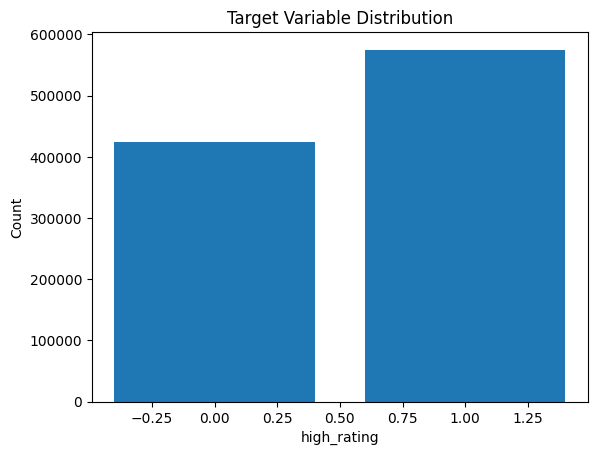

In [66]:
import matplotlib.pyplot as plt

balance_pd = balance_pert.toPandas()

plt.bar(balance_pd["high_rating"], balance_pd["count"])
plt.xlabel("high_rating")
plt.ylabel("Count")
plt.title("Target Variable Distribution")

plt.show()

####  Is the dataset balanced or imbalanced? What percentage of ratings are "high"?

The dataset contains approximately 58% high ratings(rating >= 4) and 42% low ratings. this indicates that is slightly imbalancd. However the imbalance is not extreme. 

### 3b. Numerical Feature Distributions

#### 3b.1. Histogram for user_avg_rating

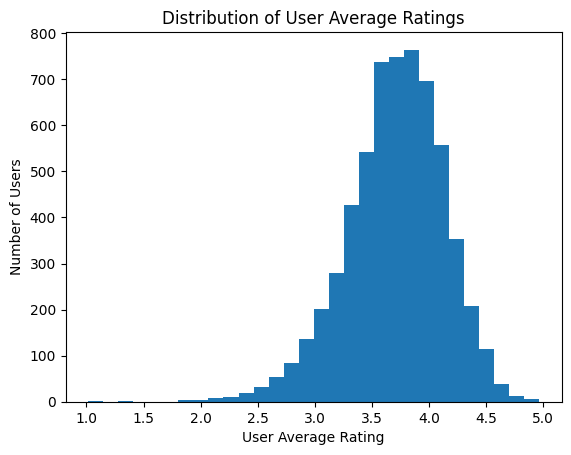

In [67]:
import matplotlib.pyplot as plt

user_avg_pd = df_joined.select("UserId","user_avg_rating") \
                .dropDuplicates(["UserId"]) \
                .toPandas()

plt.hist(user_avg_pd["user_avg_rating"], bins=30)
plt.xlabel("User Average Rating")
plt.ylabel("Number of Users")
plt.title("Distribution of User Average Ratings")
plt.savefig("user_avg_rating_histograms.png")

plt.show()

#### 3b.2. Histogram for movie_avg_rating

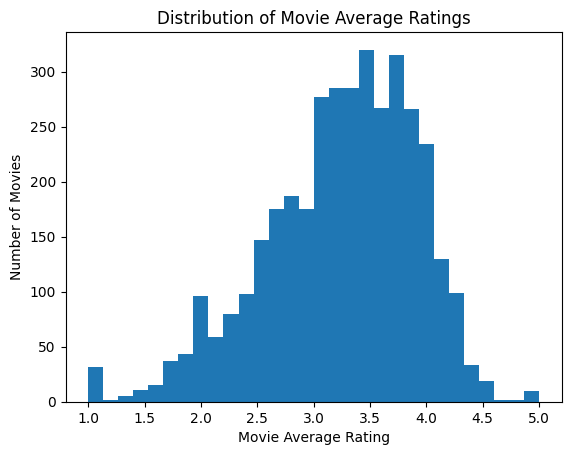

In [68]:
movie_avg_pd = df_joined.select("MovieID","movie_avg_rating") \
                 .dropDuplicates(["MovieID"]) \
                 .toPandas()

plt.hist(movie_avg_pd["movie_avg_rating"], bins=30)
plt.xlabel("Movie Average Rating")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Average Ratings")
plt.savefig("movie_avg_rating_histograms.png")

plt.show()

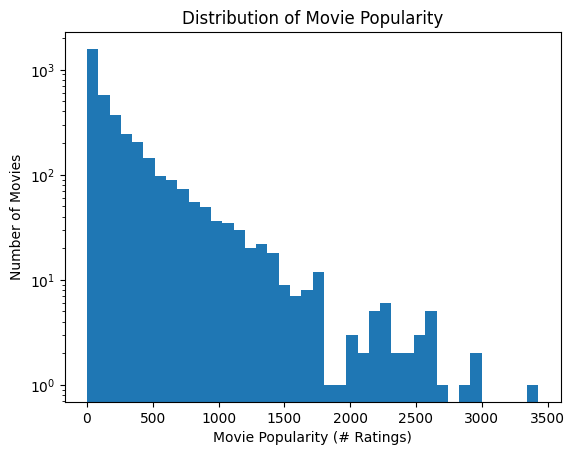

In [69]:
movie_pop_pd = df_joined.select("MovieID","movie_popularity") \
                 .dropDuplicates(["MovieID"]) \
                 .toPandas()

plt.hist(movie_pop_pd["movie_popularity"], bins=40)
plt.yscale("log")

plt.xlabel("Movie Popularity (# Ratings)")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Popularity")
plt.savefig("movie_popularity_histograms.png")
plt.show()

In [70]:
df_joined.select(
    "user_avg_rating",
    "movie_avg_rating",
    "movie_popularity"
).describe().show()

+-------+------------------+------------------+-----------------+
|summary|   user_avg_rating|  movie_avg_rating| movie_popularity|
+-------+------------------+------------------+-----------------+
|  count|           1000209|           1000209|          1000209|
|   mean|3.5815644530291726|  3.58156445302894|816.2355197763667|
| stddev| 0.436129464217158|0.5457590722646625| 662.781250869886|
|    min|1.0153846153846153|               1.0|                1|
|    max| 4.962962962962963|               5.0|             3428|
+-------+------------------+------------------+-----------------+



#### Are any features heavily skewed?

Yes. Movie popularity is heavily right-skewed. Most movies receive a relatively small number of ratings, while a small number of popular movies receive a very large number of ratings. This creates a long right tail in the distribution.

In contrast, user_avg_rating and movie_avg_rating appear roughly normally distributed. Both are centered around 3.5–4.0, with most values falling between 3.0 and 4.5.

#### Are there outliers? (e.g., movies with very few or very many ratings)

Yes. Movie popularity shows clear outliers.
- Some movies have very few ratings (close to 0–50).
- A few movies have extremely high numbers of ratings, reaching 3000+ ratings, which are far from the majority of movies.

These extreme values represent highly popular movies that attract many more ratings than typical movies.

For user_avg_rating and movie_avg_rating, there are very few extreme outliers. Most values stay within the expected rating range (1–5), and the distributions appear relatively concentrated around the mean.

#### 3c. Categorical vs. Target: Group Comparisons

For each categorical feature, compare the average high_rating rate (or average rating) across categories.
Create at least 3 of the following:
- *Gender vs. high_rating rate*: Do men or women give "high" ratings more often?
- *Age group vs. high_rating rate*: Which age group is most generous?
- *Top 10 genres vs. average rating*: Which genres get the highest ratings?
- *Occupation vs. average rating*: Do certain occupations rate differently?

#### Gender vs High Rating Rate

*Compute the average of high_rating (this gives the proportion of high ratings)*

In [71]:
from pyspark.sql.functions import avg, count, col

gender_hr = df_joined.groupBy("gender") \
    .agg(
        (avg("high_rating") * 100).alias("high_rating_pct"),
        count("*").alias("n")
    ) \
    .toPandas()

In [72]:
gender_hr

,gender,high_rating_pct,n
0,F,59.072797,246440
1,M,57.007120,753769


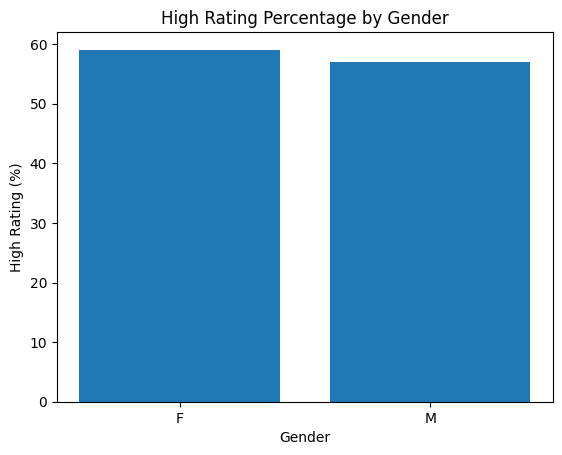

In [73]:
import matplotlib.pyplot as plt

plt.bar(gender_hr["gender"], gender_hr["high_rating_pct"])
plt.xlabel("Gender")
plt.ylabel("High Rating (%)")
plt.title("High Rating Percentage by Gender")
plt.show()

*Do men or women give "high" ratings more often?*

The high rating rate for males and females is very similar. This suggests gender has only a small influence on whether users give high ratings.


#### Age Group vs High Rating %

In [74]:
age_hr = df_joined.groupBy("age") \
    .agg(
        (avg("high_rating") * 100).alias("high_rating_pct")
    ) \
    .orderBy("age") \
    .toPandas()

In [75]:
age_hr

,age,high_rating_pct
0,1,57.366506
1,18,54.920561
2,25,56.263588
3,35,58.638814
4,45,59.158466
5,50,62.193406
6,56,64.633832


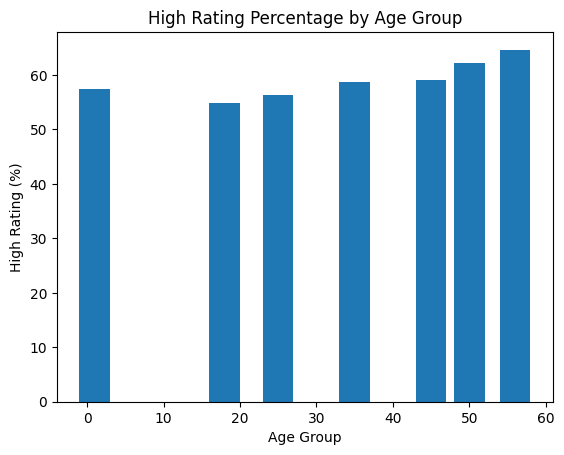

In [76]:
plt.bar(age_hr["age"], age_hr["high_rating_pct"], width=4)
plt.xlabel("Age Group")
plt.ylabel("High Rating (%)")
plt.title("High Rating Percentage by Age Group")
plt.show()

*Which age group is most generous?*

Some age(50+) groups appear slightly more generous in giving high ratings. However, the differences between age groups are relatively small, suggesting age may have limited predictive power.


#### Genre vs High Rating %

In [77]:
from pyspark.sql.functions import explode, split

genre_df = df_joined.withColumn("genre", explode(split(df_joined.Genres, "\\|")))

genre_hr = genre_df.groupBy("genre") \
    .agg((avg("high_rating") * 100).alias("high_rating_pct")) \
    .orderBy("high_rating_pct", ascending=False) \
    .limit(10) \
    .toPandas()

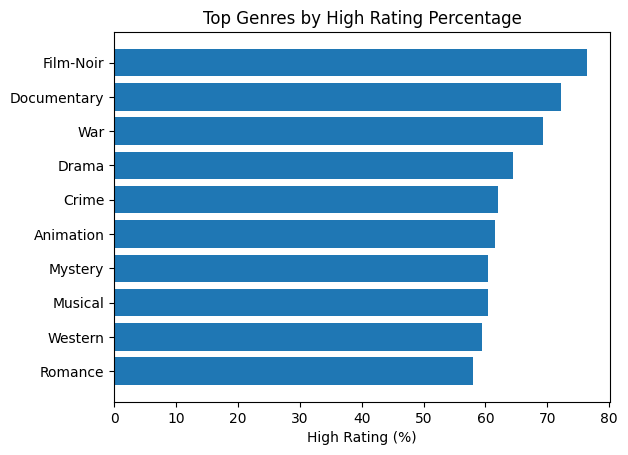

In [78]:
plt.barh(genre_hr["genre"], genre_hr["high_rating_pct"])
plt.xlabel("High Rating (%)")
plt.title("Top Genres by High Rating Percentage")
plt.gca().invert_yaxis()
plt.show()

In [79]:
genre_hr

,genre,high_rating_pct
0,Film-Noir,76.348502
1,Documentary,72.262958
2,War,69.377034
3,Drama,64.434785
4,Crime,62.039703
5,Animation,61.524958
6,Mystery,60.480860
7,Musical,60.460357
8,Western,59.522313
9,Romance,57.956386


*Which genres get the highest ratings?*

Some genres like *Film-Noir, Documentary* consistently receive higher ratings than others. This suggests genre preference may influence user ratings and could be a useful predictor in the model.

#### 3d. Numerical Feature Correlations

In [80]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


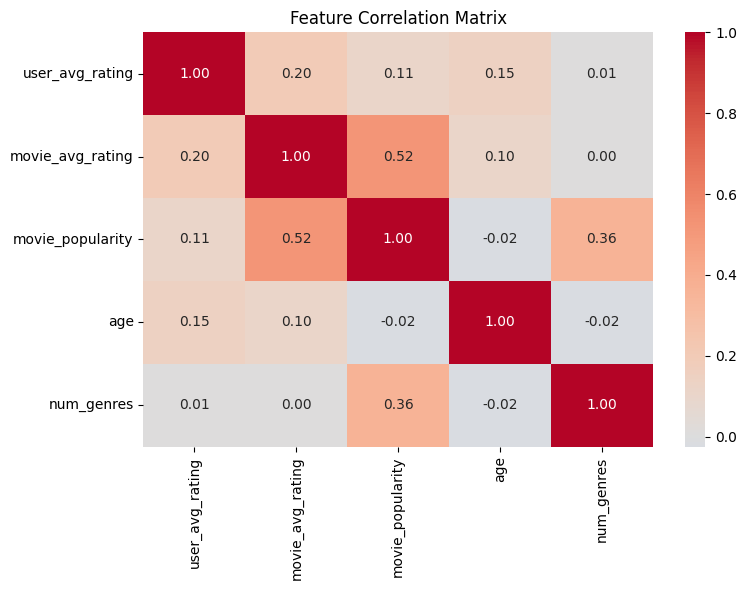

In [81]:

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import numpy as np


# Assemble numerical features into a vector

num_features = ["user_avg_rating", "movie_avg_rating",
"movie_popularity", "age", "num_genres"]
assembler = VectorAssembler(inputCols=num_features, outputCol="num_vec")
vec_df = assembler.transform(df_joined).select("num_vec")


# Compute Pearson correlation matrix
corr_matrix = Correlation.corr(vec_df, "num_vec").head()[0]
corr_array = corr_matrix.toArray()


# Visualize

import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(corr_array, annot=True, fmt=".2f",
xticklabels=num_features, yticklabels=num_features,
cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("Correlation.png")
plt.show()

##### Which pair of features has the strongest correlation?

The strongest correlation is between movie_avg_rating and movie_popularity (r ≈ 0.52). This indicates that movies with higher average ratings tend to receive more ratings, suggesting that popular movies are often rated more positively.

##### Are any features redundant (correlation > 0.8)? If so, would you drop one?

No features have correlations greater than 0.8, so none appear to be strongly redundant. Therefore, it is reasonable to keep all features for the machine learning model.


##### Which features correlate most strongly with rating?

The correlation matrix shows that the strongest relationship is between movie_avg_rating and movie_popularity (r = 0.52), indicating that movies with higher average ratings tend to receive more ratings. No feature pairs have correlations greater than 0.8, so there are no strongly redundant features that need to be removed. Among the features, movie_avg_rating and user_avg_rating are likely to be the most useful predictors of rating behavior, while age and number of genres show very weak correlations with the other variables.


#### 3e. Categorical vs. Categorical

In [82]:
from pyspark.sql.functions import explode, split, col, avg

genre_df = df_joined.withColumn(
    "genre",
    explode(split(col("genres"), "\\|"))
)
genre_df.show(10)

+------+-------+------+---------+------+---+----------+--------+--------------------+--------------------+-----------+-----------------+------------------+----------------+-----------------+--------------+----------+------------+---------+----------+
|UserID|MovieID|Rating|Timestamp|Gender|Age|Occupation|Zip-code|               Title|              Genres|high_rating|  user_avg_rating|  movie_avg_rating|movie_popularity|user_rating_count|gender_encoded|num_genres|release_year|movie_age|     genre|
+------+-------+------+---------+------+---+----------+--------+--------------------+--------------------+-----------+-----------------+------------------+----------------+-----------------+--------------+----------+------------+---------+----------+
|   148|   2467|     4|979575984|     M| 50|        17|   57747|Name of the Rose,...|             Mystery|          1|3.733974358974359|3.9012345679012346|             324|              624|             0|         1|        1986|       14|   Myste

In [83]:
genre_gender = genre_df.groupBy("genre", "gender") \
    .agg(avg("rating").alias("avg_rating")) \
    .orderBy("genre") \
    .toPandas()
genre_gender

,genre,gender,avg_rating
0,Action,F,3.490252
1,Action,M,3.491386
2,Adventure,F,3.512879
3,Adventure,M,3.468125
4,Animation,F,3.744702
5,Animation,M,3.661335
6,Children's,F,3.572548
7,Children's,M,3.358961
8,Comedy,M,3.503667
9,Comedy,F,3.571938


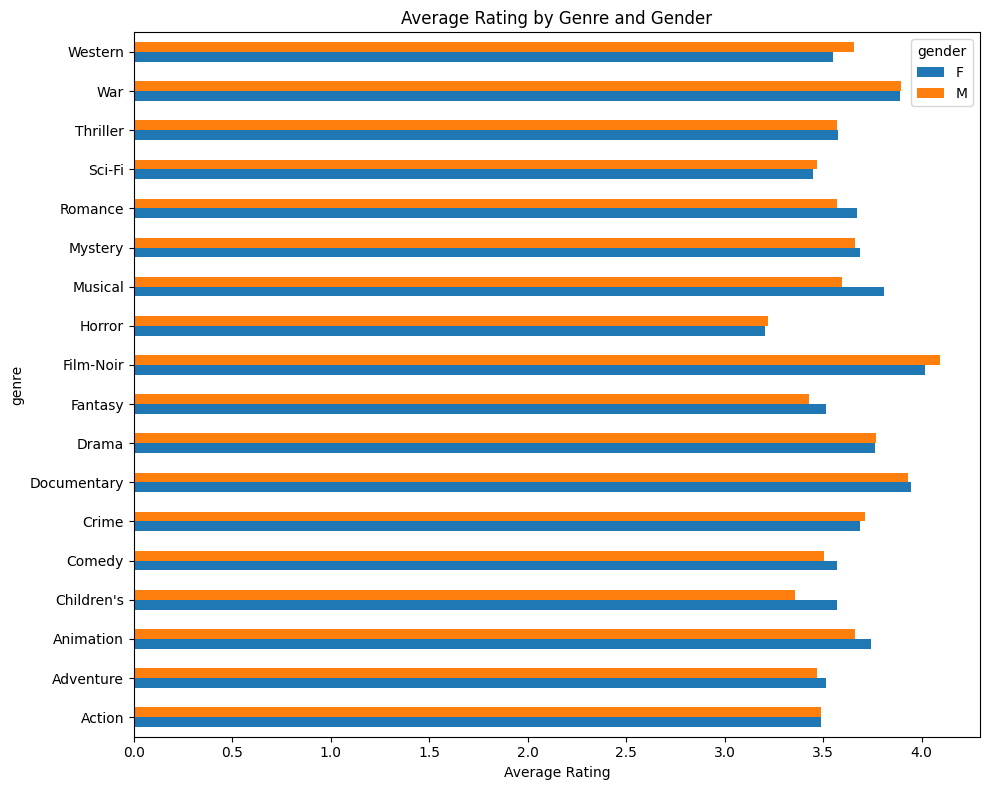

In [84]:
import matplotlib.pyplot as plt

pivot = genre_gender.pivot(
    index="genre",
    columns="gender",
    values="avg_rating"
)

pivot.plot(kind="barh", figsize=(10,8))

plt.xlabel("Average Rating")
plt.title("Average Rating by Genre and Gender")

plt.tight_layout()
plt.show()

####  Do men and women prefer different genres?

The visualization compares the average ratings given by male and female users across different movie genres. Some genres show noticeable differences between genders. For example, female users tend to give slightly higher ratings for genres such as romance and drama, while male users tend to rate action and thriller movies slightly higher. However, the differences are generally small, suggesting that genre preferences between genders are similar overall.

#### 3f. Feature-Target Summary

### Feature–Target Summary

| Feature | Type | Relationship to Target | Strength | Keep for D4? |
|--------|------|-----------------------|----------|--------------|
| `movie_avg_rating` | Numerical | Strong positive relationship with movie quality and ratings | Strong | Yes |
| `user_avg_rating` | Numerical | Users with higher historical averages tend to give higher ratings | Strong | Yes |
| `movie_popularity` | Numerical | Popular movies tend to receive more high ratings | Moderate | Yes |
| `genre` | Categorical | Certain genres consistently receive higher ratings | Moderate | Yes |
| `age` | Categorical | Older users give slightly higher percentages of high ratings | Weak | Maybe |
| `gender` | Binary | Very small difference in high rating rates between genders | Weak | Maybe |
| `occupation` | Categorical | Ratings vary little across occupations | Weak | Maybe |

---

### Most Important Features for the ML Model

Based on the exploratory data analysis, the features most likely to be important for predicting **high_rating** are:

- **`movie_avg_rating`**: A movie’s historical average rating is highly predictive of future ratings due to the *wisdom of the crowd* effect.
- **`user_avg_rating`**: Captures a user’s baseline rating behavior, distinguishing between more generous and more critical users.
- **`movie_popularity`**: Popular movies that receive many ratings tend to have a higher probability of receiving positive ratings.
- **`genre`**: Different genres show different rating patterns, which can influence the likelihood of a movie receiving a high rating.

In contrast, demographic features such as **age**, **gender**, and **occupation** showed relatively weak relationships with the target variable during the EDA. Therefore, while they may provide some additional context, they are likely to have lower predictive power compared to the rating-based features.

## Part 4: Reflection

####  Cleaning summary: What quality issues did you find (or not find)? Was anything surprising about the data quality?

During the data cleaning process, several quality checks were performed, including duplicate detection, referential integrity checks, out-of-range value validation, and a null audit. No duplicate `(UserId, MovieId)` ratings were found, indicating that each rating record is unique. All ratings fell within the valid range of 1–5, and all age and occupation codes matched the expected MovieLens categories. Referential integrity checks confirmed that all `UserId` and `MovieId` values in the ratings table exist in the corresponding users and movies tables. Overall, the dataset was surprisingly clean, which suggests that the MovieLens dataset is well-curated and suitable for analysis.

---

#### Feature Insights: Which feature do you think will be the strongest predictor of high ratings? What evidence from your EDA supports this?

Based on the exploratory data analysis, **movie_avg_rating** is likely the strongest predictor of `high_rating`. Movies with higher average ratings tend to consistently receive more positive ratings from users, reflecting a strong "wisdom of the crowd" effect. The correlation analysis also showed a moderate relationship between **movie_avg_rating and movie_popularity**, suggesting that highly rated movies tend to attract more ratings. Additionally, **user_avg_rating** captures individual user rating behavior, indicating whether a user tends to give higher or lower ratings overall. These rating-based features appear more predictive than demographic features such as age or gender.

---

#### Surprises:  Surprises: Did any feature behave differently than you expected? (e.g., a feature you thought would matter but doesn't, or vice versa)

One surprising finding was that **demographic features such as gender, age, and occupation showed relatively weak relationships with rating behavior**. Initially, it seemed likely that demographic differences would strongly influence movie preferences and ratings. However, the EDA showed only small differences in high rating percentages across these groups. Another interesting observation was the strong skew in **movie_popularity**, where a small number of movies received extremely high numbers of ratings while most movies had relatively few. This long-tail distribution is common in recommendation datasets but still highlights the imbalance in movie exposure.

---

#### Next Steps:  What additional features or transformations would you want to try in D4? List at least 2 ideas.

For the next phase (D4), several additional features or transformations could improve the predictive model. One potential feature is **movie_age**, which measures how old a movie is based on its release year and may capture temporal popularity trends. Another idea is **user_rating_count**, representing how active a user is in rating movies, which may help identify experienced reviewers. We could also create **binary genre indicators** (such as `is_action`, `is_drama`, etc.) to better capture genre preferences. Finally, interaction features between **user behavior and movie characteristics** could further improve prediction accuracy.

---

#### Limitations: What are the limitations of this dataset for building a movie recommender? (Think about what data is missing that would help.)

One limitation of the dataset is that it only contains **explicit ratings** without additional contextual information about why users rated movies a certain way. Important factors such as **watch history, viewing timestamps, or user engagement behavior** are not available. The dataset also lacks **movie metadata such as actors, directors, or production budget**, which could influence user preferences. Additionally, the dataset does not capture **changing user preferences over time**, since ratings are treated independently of temporal trends. These missing factors limit the ability to build a more personalized and dynamic recommendation system.

### Contribution Statement

**Aliia Rustamova and SHAHRIAR FAHIM**: worked on **Part 1 (Data Cleaning)** and **Part 2 (Feature Engineering)** of the project.

**Mostafizur Rahman and Rutvik Katkoriya**: contributed to the data cleaning, feature analysis, and visualization sections of the project. Implemented checks for duplicates, referential integrity, valid ranges, and null values, and helped generate histograms and categorical comparison plots such as gender vs. high rating and age vs. high rating percentage. Through this process, I learned how to use PySpark aggregations and transformations to explore large datasets and how exploratory data analysis helps identify the most useful features for machine learning models.

